# 04 · Sampling: temperature, top-p and top-k
Level L1 · Part 1 · core · ~25 min · builds on 02

## Goal
By the end of this lesson you can change **temperature**, **top-k** and **top-p** on a toy next-word
distribution, predict what each one does before you run it, and explain why temperature 0 is still
not fully repeatable and why the newest Claude models refuse these settings.

## The idea
In lesson 02 our code always took the most likely next token (greedy decoding). Real models usually
**sample**: they roll a weighted die over the candidates. Before the roll, three knobs reshape the die.
**Temperature** sharpens it (low) or flattens it (high). **Top-k** throws away all but the k best faces.
**Top-p** keeps the fewest faces that together hold probability p. The model's scores do not change;
only the picking rule does.

Analogy: choosing a restaurant. Temperature 0 is "always the favourite". High temperature is
"anything goes". Top-k is "only my top 3". Top-p is "only the places that make up 90% of my visits".

## Picture
```mermaid
flowchart LR
    L[Model scores<br/>logits] --> T[Divide by<br/>temperature]
    T --> S[softmax:<br/>probabilities]
    S --> K[top-k: keep k best]
    K --> P[top-p: keep smallest set<br/>summing to p]
    P --> R[Renormalise<br/>and roll the die]
    R --> N[Next token]
```

## Step by step
### 1. Raw scores for the word after "Mars is"
A real model does not output probabilities directly. It outputs one raw score per token, called a
**logit**. Higher is more likely; the numbers can be negative. Here are made-up logits for eight
candidates after the prompt "Mars is". They play the part of a bigger model than our bigram from lesson 02.

In [1]:
LOGITS = {
    "red": 3.0, "a": 2.2, "the": 1.8, "cold": 1.2,
    "small": 0.8, "far": 0.3, "purple": -1.0, "banana": -3.0,
}
print(len(LOGITS), "candidates; best:", max(LOGITS, key=LOGITS.get))

8 candidates; best: red


### 2. Softmax turns scores into probabilities
**Softmax** makes every score positive with `exp`, then divides by the total so they add up to 1.
Subtracting the largest score first changes nothing in the result but keeps `exp` from overflowing.

In [2]:
import math

def softmax(logits: dict[str, float]) -> dict[str, float]:
    top = max(logits.values())
    exps = {tok: math.exp(s - top) for tok, s in logits.items()}
    total = sum(exps.values())
    return {tok: e / total for tok, e in exps.items()}

probs = softmax(LOGITS)
for tok, p in probs.items():
    print(f"{tok:>7}  {p:.3f}  {'#' * round(p * 50)}")
print("sum:", round(sum(probs.values()), 6))

    red  0.473  ########################
      a  0.212  ###########
    the  0.142  #######
   cold  0.078  ####
  small  0.052  ###
    far  0.032  ##
 purple  0.009  
 banana  0.001  
sum: 1.0


"red" gets about 47%, "banana" about 0.1%. A gap of 1 in logits means about 2.7 times
(that is `e`) more likely.

### 3. Temperature: divide the scores before softmax
**Temperature** T divides every logit before softmax. T below 1 stretches the gaps, so the leader wins
more often. T above 1 shrinks the gaps, so rare words get a real chance. Predict first: at T = 0.2,
what is P("red")? At T = 2?

In [3]:
def apply_temperature(logits: dict[str, float], t: float) -> dict[str, float]:
    return softmax({tok: s / t for tok, s in logits.items()})

for t in [0.2, 0.7, 1.0, 1.5, 2.0]:
    p = apply_temperature(LOGITS, t)
    print(f"T={t:<4} red={p['red']:.3f}  purple={p['purple']:.3f}  banana={p['banana']:.4f}")

T=0.2  red=0.979  purple=0.000  banana=0.0000
T=0.7  red=0.609  purple=0.002  banana=0.0001
T=1.0  red=0.473  purple=0.009  banana=0.0012
T=1.5  red=0.354  purple=0.025  banana=0.0065
T=2.0  red=0.294  purple=0.040  banana=0.0146


At T = 0.2 "red" takes about 98%: almost greedy. At T = 2 it drops to about 29% and "purple" rises
from about 1% to about 4%. Same model, same scores, very different behaviour.

### 4. Plot the distributions
Four temperatures side by side make the effect visible.

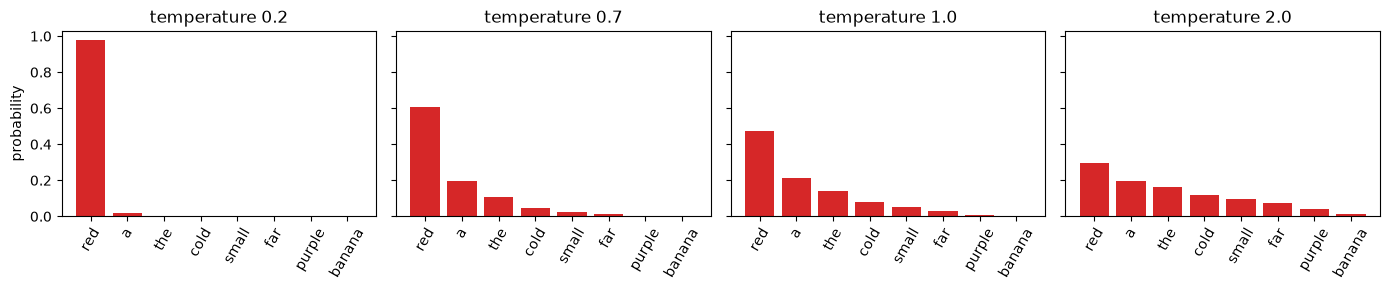

In [4]:
import matplotlib.pyplot as plt

temps = [0.2, 0.7, 1.0, 2.0]
fig, axes = plt.subplots(1, len(temps), figsize=(14, 3), sharey=True)
for ax, t in zip(axes, temps):
    p = apply_temperature(LOGITS, t)
    ax.bar(list(p), list(p.values()), color="tab:red")
    ax.set_title(f"temperature {t}")
    ax.tick_params(axis="x", labelrotation=60)
axes[0].set_ylabel("probability")
plt.tight_layout()
plt.show()

### 5. Sampling: roll the weighted die
**Sampling** picks a token at random, in proportion to its probability. We pass a seeded
`random.Random` so the notebook gives the same numbers every run. Over 1,000 draws the counts
should match the probabilities.

In [5]:
import random
from collections import Counter

def sample(probs: dict[str, float], rng: random.Random) -> str:
    return rng.choices(list(probs), weights=list(probs.values()), k=1)[0]

rng = random.Random(42)
for t in [0.2, 1.0, 2.0]:
    p = apply_temperature(LOGITS, t)
    draws = Counter(sample(p, rng) for _ in range(1000))
    print(f"T={t}: {dict(draws.most_common())}")

T=0.2: {'red': 974, 'a': 20, 'the': 5, 'cold': 1}
T=1.0: {'red': 465, 'a': 227, 'the': 153, 'cold': 71, 'small': 47, 'far': 28, 'purple': 8, 'banana': 1}
T=2.0: {'red': 296, 'a': 191, 'the': 158, 'cold': 118, 'small': 103, 'far': 61, 'purple': 51, 'banana': 22}


At T = 0.2 nearly every draw is "red". At T = 2 even "banana" shows up now and then. That is why
high temperature feels "creative" and also why it says odd things.

### 6. Top-k: keep only the k best
**Top-k** sorts the candidates, keeps the k most likely, and **renormalises** (divides by the kept
total so they sum to 1 again). Everything else gets probability 0, so it can never be picked.

In [6]:
def top_k(probs: dict[str, float], k: int) -> dict[str, float]:
    kept = sorted(probs.items(), key=lambda kv: kv[1], reverse=True)[:k]
    total = sum(p for _, p in kept)
    return {tok: p / total for tok, p in kept}

for tok, p in top_k(softmax(LOGITS), k=3).items():
    print(f"{tok:>5}  {p:.3f}")

  red  0.571
    a  0.257
  the  0.172


"red", "a" and "the" share all the probability; "banana" is gone for good. The weakness: k is fixed.
When the model is sure, k = 3 still keeps two poor options; when it is unsure, k = 3 may cut good ones.

### 7. Top-p: keep the smallest set that covers p
**Top-p** (also called **nucleus sampling**) walks down the sorted list, adding probabilities until the
total reaches p, and keeps exactly those tokens. The number kept adapts to how sure the model is.

In [7]:
def top_p(probs: dict[str, float], p: float) -> dict[str, float]:
    kept, total = {}, 0.0
    for tok, q in sorted(probs.items(), key=lambda kv: kv[1], reverse=True):
        kept[tok] = q
        total += q
        if total >= p:          # include the token that crosses p, then stop
            break
    return {tok: q / total for tok, q in kept.items()}

for t in [0.5, 1.0, 2.0]:
    kept = top_p(apply_temperature(LOGITS, t), p=0.9)
    print(f"T={t}: top-p 0.9 keeps {len(kept)} tokens: {list(kept)}")

T=0.5: top-p 0.9 keeps 3 tokens: ['red', 'a', 'the']
T=1.0: top-p 0.9 keeps 4 tokens: ['red', 'a', 'the', 'cold']
T=2.0: top-p 0.9 keeps 6 tokens: ['red', 'a', 'the', 'cold', 'small', 'far']


Same p = 0.9, but 3 tokens survive at T = 0.5 and 6 at T = 2. Top-p follows the shape of the
distribution; top-k does not.

### 8. One sampler with all three knobs
A common order is: temperature, then top-k, then top-p, then roll. Libraries differ in the details.
Temperature 0 cannot divide, so by convention it means greedy: take the top token.

In [8]:
def pick(logits, rng, temperature=1.0, k=None, p=None) -> str:
    if temperature == 0:
        return max(logits, key=logits.get)          # greedy, as in lesson 02
    probs = apply_temperature(logits, temperature)
    if k is not None:
        probs = top_k(probs, k)
    if p is not None:
        probs = top_p(probs, p)
    return sample(probs, rng)

rng = random.Random(0)
for settings in [dict(temperature=0), dict(temperature=1.0), dict(temperature=1.0, k=2), dict(temperature=1.5, p=0.8)]:
    words = [pick(LOGITS, rng, **settings) for _ in range(12)]
    print(f"{str(settings):38} {' '.join(words)}")

{'temperature': 0}                     red red red red red red red red red red red red
{'temperature': 1.0}                   cold the red red a red the red a a small a
{'temperature': 1.0, 'k': 2}           red a red red a a a a red a a red
{'temperature': 1.5, 'p': 0.8}         a red a a cold cold a the red the a red


### 9. Plug the sampler into lesson 02's model
Setup from lesson 02: Scout's notes, the tokenizer and the bigram counts. A count is not a logit, but
`log(count)` is: softmax of `log(count)` gives back exactly count / total. So temperature works on it too.

In [9]:
import re
from collections import defaultdict

NOTES = [
    {"id": 1, "text": "Mars has two small moons, Phobos and Deimos."},
    {"id": 2, "text": "Venus spins backwards compared with most planets."},
    {"id": 3, "text": "A day on Mars lasts about 24 hours and 39 minutes."},
    {"id": 4, "text": "Jupiter is the largest planet in the solar system."},
    {"id": 5, "text": "The rover Perseverance landed on Mars in February 2021."},
    {"id": 6, "text": "Saturn's rings are mostly made of ice."},
]
START, END = "<s>", "</s>"

def tokenize(text: str) -> list[str]:
    return re.findall(r"[\w']+|[.,!?]", text)

counts = defaultdict(Counter)
for seq in ([START] + tokenize(n["text"]) + [END] for n in NOTES):
    for prev, nxt in zip(seq, seq[1:]):
        counts[prev][nxt] += 1
counts = dict(counts)

def bigram_logits(prev: str) -> dict[str, float]:
    return {tok: math.log(n) for tok, n in counts[prev].items()}

print({tok: round(p, 3) for tok, p in softmax(bigram_logits("the")).items()})

{'largest': 0.5, 'solar': 0.5}


Now `generate` from lesson 02, with `pick` in place of `pick_greedy`. In lesson 02 "Jupiter" looped
forever under greedy decoding. Let's run it with temperature 0 and with temperature 1 under four seeds.

In [10]:
def generate(prompt, rng, max_tokens=15, **knobs) -> tuple[str, str]:
    tokens, new = [START] + tokenize(prompt), []
    for _ in range(max_tokens):
        nxt = pick(bigram_logits(tokens[-1]), rng, **knobs)
        if nxt == END:
            return " ".join(new), "end_token"
        tokens.append(nxt)
        new.append(nxt)
    return " ".join(new), "max_tokens"

print("T=0  ", generate("Jupiter", random.Random(0), temperature=0))
for seed in range(4):
    print(f"T=1 seed {seed}", generate("Jupiter", random.Random(seed), temperature=1.0))

T=0   ('is the largest planet in the largest planet in the largest planet in the largest', 'max_tokens')
T=1 seed 0 ('is the largest planet in the solar system .', 'end_token')
T=1 seed 1 ('is the solar system .', 'end_token')
T=1 seed 2 ('is the largest planet in February 2021 .', 'end_token')
T=1 seed 3 ('is the largest planet in the largest planet in the solar system .', 'end_token')


Temperature 0 repeats lesson 02's loop and hits `max_tokens`. With temperature 1, each seed takes a
different path. Here all four escape and reach `</s>`, but seed 2 glues two notes into
"Jupiter is the largest planet in February 2021", which is nonsense. Randomness
helps avoid repetition, but it does not make the text true.

### 10. Why temperature 0 is still not fully repeatable
With temperature 0 you might expect the same answer every time from an API. Often you get it, but not
always. A logit is the result of millions of additions. In floating point, the order of additions
changes the last digit:

In [11]:
order_a = (0.1 + 0.2) + 0.3
order_b = 0.1 + (0.2 + 0.3)
print(repr(order_a), repr(order_b), order_a == order_b)

0.6000000000000001 0.6 False


A server runs your request in a **batch** with other users' requests. The batch size, and the
GPU type, can change how the hardware splits those sums, so the order can change. When two tokens are
almost tied, a last-digit change can flip which one is on top.

The next cell is a hand-made illustration with plain Python floats, not a recording from a real GPU
or API. It shows the mechanism only. Remember that greedy picks the *first* of an exact tie (`max`
returns the first one it meets); that is how lesson 02's "the" row always chose "largest" and looped.

In [12]:
def scores_in_batch(order: str) -> dict[str, float]:
    red = (0.1 + 0.2) + 0.3 if order == "a" else 0.1 + (0.2 + 0.3)   # same maths, different order
    return {"a": 0.6, "red": red}

for order in ["a", "b"]:
    s = scores_in_batch(order)
    print(f"batch layout {order}: scores={s} -> greedy picks {max(s, key=s.get)!r}")

batch layout a: scores={'a': 0.6, 'red': 0.6000000000000001} -> greedy picks 'red'
batch layout b: scores={'a': 0.6, 'red': 0.6} -> greedy picks 'a'


One different token early on changes everything after it, because each token is fed back in
(lesson 02). So: temperature 0 means "much less random", not "guaranteed identical".

### 11. Not every model lets you turn the knobs
The newest Claude models (Opus 4.7 and later, including Opus 5.5, Sonnet 5.5 and Fable 5.1) **reject**
a non-default `temperature`, `top_p` or `top_k` with a 400 error. Claude Haiku 4.5 still accepts them.
Gemini 3.x accepts `temperature`; the default is 1.0 and the docs give no tuning advice, so most code
leaves it alone. Newer models are
steered by a reasoning **effort** setting instead (lesson 40). A safe habit is to build request settings
from a per-model rule, not to send knobs everywhere:

In [13]:
# The rule as of this course's research date; lesson 17 moves it into config.
NO_SAMPLING_KNOBS = {"claude-opus-4-7", "claude-opus-5-5", "claude-sonnet-5-5", "claude-fable-5-1"}

def sampling_params(model: str, temperature: float | None = None) -> dict:
    if temperature is None or model in NO_SAMPLING_KNOBS:
        return {}                    # let the provider use its default
    return {"temperature": temperature}

for model in ["claude-haiku-4-5", "claude-opus-5-5", "gemini-3.5-flash-lite"]:
    print(f"{model:22} -> {sampling_params(model, temperature=0.2)}")

claude-haiku-4-5       -> {'temperature': 0.2}
claude-opus-5-5        -> {}
gemini-3.5-flash-lite  -> {'temperature': 0.2}


This only builds a dictionary; no API is called. Real calls start in lesson 07, and lesson 17 shows how
to keep model ids and their rules in one config.

## At work
- **Model upgrades break on sampling settings.** Code that sends `temperature=0.2` to Claude Haiku 4.5
  gets a 400 error after switching to Opus 5.5 or Sonnet 5.5. Teams keep model ids and per-model settings
  in config and run evals before swapping. → lesson 17, lesson 53
- **Nobody tests agents by hoping temperature 0 repeats.** Unit tests use a scripted fake model, and
  integration tests replay recorded responses. → lesson 46, lesson 47
- **Evals run each case several times.** Because outputs vary even at temperature 0, quality is measured as
  a pass rate over repeats, not one lucky run. → lesson 48
- **Effort replaces temperature on reasoning models.** Anthropic's `effort`, OpenAI's `reasoning.effort` and
  Gemini's `thinking_level` are the knobs teams tune now. → lesson 40

## What just happened
- `softmax` turned eight logits for "Mars is ..." into probabilities: "red" about 47%.
- `apply_temperature` divided logits by T: T = 0.2 made "red" about 98%; T = 2 gave "purple" about 4%.
- `sample` rolled a seeded weighted die; 1,000 draws matched the probabilities.
- `top_k` kept a fixed number of tokens; `top_p` kept as many as needed to reach p (3 at T = 0.5, 6 at T = 2).
- `pick` combined all three; with it, lesson 02's "Jupiter" loop sometimes escaped at T = 1.
- Adding the same floats in a different order changed the last digit and flipped a near-tie.
- `sampling_params` sends no knobs to models that reject them.

## Common mistakes
**1. Dividing by a temperature of 0.** Temperature 0 is a special case, not a number you can divide by.

In [14]:
apply_temperature(LOGITS, 0)

ZeroDivisionError: float division by zero

Fix: treat 0 as greedy before any division, as `pick` does: `pick(LOGITS, rng, temperature=0)`.

**2. A top-p filter that can keep nothing.** This version stops *before* the token that crosses p.
When the top token alone is above p (here "red" is about 98% at T = 0.2), nothing is kept and the roll fails.

In [15]:
def top_p_wrong(probs, p):
    kept, total = {}, 0.0
    for tok, q in sorted(probs.items(), key=lambda kv: kv[1], reverse=True):
        if total + q > p:
            break
        kept[tok] = q
        total += q
    return kept

sample(top_p_wrong(apply_temperature(LOGITS, 0.2), p=0.9), random.Random(0))

IndexError: list index out of range

Fix: always keep the token that crosses p, so at least one survives. Our `top_p` adds the token first,
then checks:

In [16]:
print(top_p(apply_temperature(LOGITS, 0.2), p=0.9))

{'red': 1.0}


## Try it
1. Predict, then check: with `top_k(apply_temperature(LOGITS, 0.5), k=2)`, which two words survive, and is
   "red" above or below 80%? Print the result.
2. Run `generate("Jupiter", random.Random(seed), temperature=0.5)` and
   `generate("Jupiter", random.Random(seed), temperature=1.5)` for seeds 0 to 19. Count how many runs end
   with `end_token` at each temperature. Predict first: which temperature escapes the loop more often?
   Explain the result using `softmax(bigram_logits("the"))` from step 9.
   Hint: also look at the counts after "in".

In [17]:
# your code here

## Key terms
- **logit** — the raw score a model gives each possible next token before it becomes a probability; can be negative.
- **softmax** — turns logits into probabilities: `exp` of each score divided by the sum of all of them.
- **sampling** — picking the next token at random, weighted by its probability, instead of always the top one.
- **temperature** — divides logits before softmax; below 1 sharpens the distribution, above 1 flattens it; 0 means greedy.
- **top-k** — keep only the k most likely tokens, renormalise, then sample.
- **top-p (nucleus sampling)** — keep the smallest set of top tokens whose probabilities add up to at least p, renormalise, then sample.
- **renormalise** — divide the kept probabilities by their total so they add up to 1 again.